## 1. Importação das bibliotecas:

In [1]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aurel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import sys

import transformers
import keras
import tf_keras

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AdamW
)

from torchinfo import summary

from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, MultiHeadAttention, LayerNormalization,
                                    Dropout,Dense,  GlobalAveragePooling1D, Add)

from nltk.corpus import stopwords
from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#STOPWORDS = set(stopwords.words('portuguese'))
STOPWORDS = set(stopwords.words('portuguese') + list(punctuation))


c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("tf_keras:", tf_keras.__version__)
print("Transformers:", transformers.__version__)

print("--------------------------------")

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TensorFlow: 2.18.0
Keras: 3.8.0
tf_keras: 2.18.0
Transformers: 4.48.3
--------------------------------
2.12.1+cu126
True
NVIDIA GeForce RTX 3060


## 2. Configuração dos parâmetros:

In [4]:
# Parâmetros Principais

# Tamanho do vocabulário a ser criado com o tokenizer. Este considera as N palavras mais comuns (ou frequentes nos textos)
vocab_size = 5000 # 2500 ou 10000

# Tamanho do vetor de características que representa cada palavra. Cada palavra é transformada para um vetor com 64 entradas.
embedding_dim = 128  # 64 ou 256

# Tamanho máximo da sequência de códigos que representa um texto (tamanho do feature vector)
max_length = 20  # 15 ou 25

# Tipo de truncagem a ser utilizado, 'post' significa remover valores do final da sequência.
trunc_type = 'post'

# Tipo de padding a ser utilizado, 'post' significa completar no final da sequência.
padding_type = 'post'

# Token a ser utilizado quando uma palavra não presente no vocabulário é encontrada no texto
Not_known = '<NKN>'

# Porcentagem de instâncias a ser utilizada no treinamento
training_portion = .7

# Numero de épocas a ser utilizado no treinamento
num_epochs = 20


In [5]:
try:
    random_seed
except NameError:
    random_seed = 42
    
print("Executando seed:", random_seed)

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)

# garante maior reprodutibilidade na GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Executando seed: 42


## 3. Carregando a base de dados:

In [6]:
df_texto = pd.concat([
    pd.read_csv("g1_v1_ws.csv", sep=";", encoding="latin-1"),
    pd.read_csv("g1_v2_ws.csv", sep=";", encoding="latin-1")
], ignore_index=True)

df_texto.head()

,texto,;,classe
0,Ney Latorraca melhora e pode deixar CTI na sem...,;,alegria
1,Rato é encontrado em lata de feijões na França...,;,surpresa
2,Cientistas criam câmera mais rápida do mundo ...,;,alegria
3,Programa em MG aumenta uso de métodos anticon...,;,alegria
4,"Alencar é transferido para quarto, diz boleti...",;,alegria


In [7]:
df_texto.shape

(2732, 3)

## 4. Analise exploratória:

In [8]:
df_texto['classe'].nunique()


7

In [9]:
set(df_texto['classe'])

{'alegria', 'desgosto', 'medo', 'neutro', 'raiva', 'surpresa', 'tristeza'}

In [10]:
df_texto.isnull().sum()

texto     0
;         0
classe    0
dtype: int64

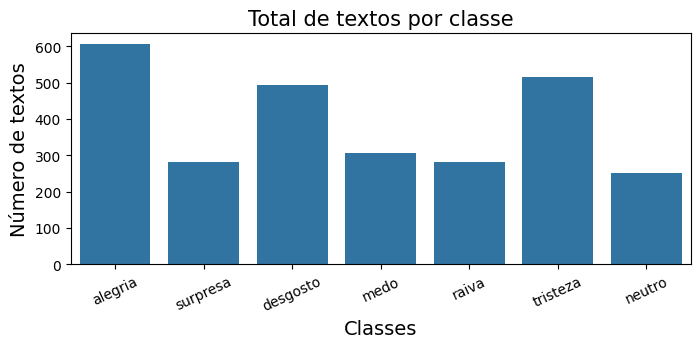

In [11]:
plt.figure(figsize=(8,3))
sns.countplot(data=df_texto, x='classe')
plt.title("Total de textos por classe", size=15)
plt.xlabel("Classes", size=14)
plt.xticks(rotation=25)
plt.ylabel("Número de textos", size=14)
plt.show()

In [12]:
df_texto['classe'].value_counts()

classe
alegria     605
tristeza    515
desgosto    494
medo        306
surpresa    281
raiva       281
neutro      250
Name: count, dtype: int64

## 5. Pré-Processamento:

### 5.1 Limpeza dos dados.

In [13]:
# Carrega os textos. Em X o texto de entrada e em y os rótulos.
# Cada linha do texto carregada é filtrada para retirada de stopwords.

X = []
y = []

def limpeza_texto(df):
    for _, linha in df.iterrows():    # processa cada linha do texto
        aux = str(linha["texto"])
        classe = linha["classe"]
        for word in STOPWORDS:        # retirada de stopwords
            aux = aux.replace(f" {word} ", " ")
        X.append(aux)
        y.append(classe)

limpeza_texto(df_texto)

In [14]:
print(len(y))       # quantidade de rótulos
print(len(X))       # quantidade de textos

total_chars_original = df_texto['texto'].apply(len).sum()
total_chars_limpo = sum(len(x) for x in X)

print(f"Tamanho de caracteres antes da limpeza: {total_chars_original}")
print(f"Tamanho de caracteres depois da limpeza: {total_chars_limpo}")

2732
2732
Tamanho de caracteres antes da limpeza: 522718
Tamanho de caracteres depois da limpeza: 435225


### 5.2 Conversão pelo dicionário. 

In [15]:
# Classificação Binária: positivo ou negativo

dic_bin = {'neutro':'positivo', 'alegria':'positivo', 'surpresa':'positivo', 'medo':'negativo', 'raiva':'negativo', 'desgosto':'negativo', 'tristeza':'negativo'}
y_bin=[dic_bin.get(n, n) for n in y]

# para a base de N classes mantem o original
y_Mult = y

print(set(y_bin))
print(set(y_Mult))


{'positivo', 'negativo'}
{'raiva', 'surpresa', 'neutro', 'desgosto', 'medo', 'tristeza', 'alegria'}


### 5.3 Train/Test Split.

In [16]:
# (Binario)
train_X, validation_X, train_y, validation_y = train_test_split(X,y_bin,test_size=.3, random_state=random_seed, stratify=y)

# Para o Transformer (Bertimbau)
label_encoder = LabelEncoder()
y_train_Tf_enc = label_encoder.fit_transform(train_y)
y_validation_Tf_enc = label_encoder.transform(validation_y)

print(train_y)
print(validation_y)
print(set(y_bin))

['positivo', 'negativo', 'negativo', 'positivo', 'negativo', 'negativo', 'negativo', 'negativo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'positivo', 'positivo', 'positivo', 'negativo', 'positivo', 'negativo', 'negativo', 'negativo', 'negativo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'negativo', 'positivo', 'negativo', 'negativo', 'negativo', 'positivo', 'positivo', 'positivo', 'negativo', 'positivo', 'positivo', 'negativo', 'positivo', 'negativo', 'negativo', 'positivo', 'positivo', 'positivo', 'negativo', 'negativo', 'negativo', 'positivo', 'negativo', 'negativo', 'positivo', 'positivo', 'negativo', 'negativo', 'positivo', 'positivo', 'negativo', 'negativo', 'negativo', 'negativo', 'negativo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'positivo', 'negativo', 'negativo', 'negativo', 'negativo', 'negativo', 'positivo', 'positivo', 'positivo', 'negativo', 'positivo', 'positivo', 'ne

In [17]:
# (Multiclasse)
train_X_Mult, validation_X_Mult, train_y_Mult, validation_y_Mult = train_test_split(X,y_Mult,test_size=.3, random_state=random_seed, stratify=y)

# Para o Transformer (Bertimbau)
label_encoder_Mult = LabelEncoder()
y_train_Tf_enc_Mult = label_encoder_Mult.fit_transform(train_y_Mult)
y_validation_Tf_enc_Mult = label_encoder_Mult.transform(validation_y_Mult)

print(train_y_Mult)
print(validation_y_Mult)
print(set(y_Mult))

['alegria', 'medo', 'medo', 'alegria', 'tristeza', 'desgosto', 'tristeza', 'desgosto', 'desgosto', 'alegria', 'desgosto', 'neutro', 'desgosto', 'surpresa', 'alegria', 'surpresa', 'medo', 'surpresa', 'desgosto', 'raiva', 'desgosto', 'raiva', 'medo', 'neutro', 'raiva', 'surpresa', 'tristeza', 'desgosto', 'surpresa', 'medo', 'tristeza', 'medo', 'alegria', 'alegria', 'alegria', 'tristeza', 'alegria', 'alegria', 'medo', 'alegria', 'tristeza', 'desgosto', 'alegria', 'alegria', 'neutro', 'tristeza', 'desgosto', 'tristeza', 'surpresa', 'tristeza', 'tristeza', 'neutro', 'surpresa', 'tristeza', 'tristeza', 'alegria', 'surpresa', 'tristeza', 'tristeza', 'desgosto', 'tristeza', 'tristeza', 'tristeza', 'neutro', 'raiva', 'alegria', 'desgosto', 'neutro', 'tristeza', 'alegria', 'tristeza', 'alegria', 'raiva', 'raiva', 'desgosto', 'tristeza', 'desgosto', 'surpresa', 'neutro', 'surpresa', 'medo', 'alegria', 'neutro', 'desgosto', 'surpresa', 'desgosto', 'tristeza', 'tristeza', 'tristeza', 'raiva', 'surp

### 5.4 Tokenização.

In [18]:
# Cria o vocabulário a partir da base de treinamento considerando o tamanho definido em vocab_size.
# Utiliza como coringa o símbolo Not_known
tokenizer = Tokenizer(num_words = vocab_size, oov_token=Not_known)
tokenizer.fit_on_texts(train_X)
word_index = tokenizer.word_index
tokenizer.num_words

5000

In [19]:
# Para Multiclasse
tokenizer_Mult = Tokenizer(num_words = vocab_size, oov_token=Not_known)
tokenizer_Mult.fit_on_texts(train_X_Mult)
word_index_Mult = tokenizer_Mult.word_index
tokenizer_Mult.num_words

5000

In [20]:
# Converte uma linha de texto em uma sequência de valores
train_sequences = tokenizer.texts_to_sequences(train_X)

# Mult
train_sequences_Mult = tokenizer_Mult.texts_to_sequences(train_X_Mult)

In [21]:
# Mostra uma linha de texto convertida para sequência de valores
# Cada valor representa uma palavra do vocabulário
print(train_X[5])
print(train_sequences[5])


# Mult
print(train_X_Mult[5])
print(train_sequences_Mult[5])

Berlim Hamburgo vivem noite distúrbios: Dois mil soldados deslocados controlar manifestações. Cerca 30 pessoas detidas.
[2540, 1905, 1552, 105, 1553, 29, 20, 1291, 3297, 1106, 1292, 73, 194, 14, 2541]
Berlim Hamburgo vivem noite distúrbios: Dois mil soldados deslocados controlar manifestações. Cerca 30 pessoas detidas.
[2540, 1905, 1552, 105, 1553, 29, 20, 1291, 3297, 1106, 1292, 73, 194, 14, 2541]


In [22]:
tokenizer_Tf = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

In [23]:
# Transformer Binario

train_encodings_Tf = tokenizer_Tf(list(train_X), truncation=True, padding=True, max_length=128, return_tensors='pt')
validation_encodings_Tf = tokenizer_Tf(list(validation_X), truncation=True, padding=True, max_length=128, return_tensors='pt')


In [24]:
# Transformer Multiclasse
train_encodings_Tf_Mult = tokenizer_Tf(list(train_X_Mult), truncation=True, padding=True, max_length=128, return_tensors='pt')
validation_encodings_Tf_Mult = tokenizer_Tf(list(validation_X_Mult), truncation=True, padding=True, max_length=128, return_tensors='pt')


### 5.5 Padding.

In [25]:
# Transforma todas as sequências para um tamanho fixo. Sequências pequenas são completadas e sequências maiores que o limite são truncadas
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Mult
train_padded_Mult = pad_sequences(train_sequences_Mult, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [26]:
# Imprime uma sequência
print(train_sequences[6])
print(train_padded[6])

# Imprime uma sequência do Multiclasse
print(train_sequences_Mult[6])
print(train_padded_Mult[6])

[459, 50, 204, 102, 151, 11, 13, 72, 29, 218, 4, 460, 1906, 52, 833, 425, 61, 1, 41, 40, 2542, 229, 1293, 22]
[ 459   50  204  102  151   11   13   72   29  218    4  460 1906   52
  833  425   61    1   41   40]
[459, 50, 204, 102, 151, 11, 13, 72, 29, 218, 4, 460, 1906, 52, 833, 425, 61, 1, 41, 40, 2542, 229, 1293, 22]
[ 459   50  204  102  151   11   13   72   29  218    4  460 1906   52
  833  425   61    1   41   40]


In [27]:
# Tokeniza a base de validação.

validation_sequences = tokenizer.texts_to_sequences(validation_X)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Mult
validation_sequences_Mult = tokenizer_Mult.texts_to_sequences(validation_X_Mult)
validation_padded_Mult = pad_sequences(validation_sequences_Mult, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(len(validation_sequences))
print(validation_padded.shape)

print(len(validation_sequences_Mult))
print(validation_padded_Mult.shape)

820
(820, 20)
820
(820, 20)


### 5.6 Labels.

In [28]:
# Tokeniza os rótulos
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(y_bin)

# Tokeniza os rótulos para a classificação multiclasse
label_tokenizer_Mult = Tokenizer()
label_tokenizer_Mult.fit_on_texts(y_Mult)

label_index = label_tokenizer.word_index
label_index_Mult = label_tokenizer_Mult.word_index
print(label_index)
print(label_index_Mult)

# Observe que subtraímos 1 dos códigos para que comecem em 0
training_label_seq = np.array(label_tokenizer.texts_to_sequences(train_y))-1
validation_label_seq = np.array(label_tokenizer.texts_to_sequences(validation_y))-1

# Multiclasse
training_label_seq_Mult = np.array(label_tokenizer_Mult.texts_to_sequences(train_y_Mult))-1
validation_label_seq_Mult = np.array(label_tokenizer_Mult.texts_to_sequences(validation_y_Mult))-1

{'negativo': 1, 'positivo': 2}
{'alegria': 1, 'tristeza': 2, 'desgosto': 3, 'medo': 4, 'surpresa': 5, 'raiva': 6, 'neutro': 7}


In [29]:
# Confere como ficaram as nossas frases depois de transformdas
# Apenas para conferência.

reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_article(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])
print(decode_article(train_padded[50]))
print('---')
print(train_X[50])
print(train_y[50])

explosão mata dois espanha ataque destruiu carro quartel guarda civil ilha mallorca na quarta carro bomba feriu 60 norte país
---
 Explosão mata dois Espanha Ataque destruiu carro quartel guarda civil ilha Mallorca. Na quarta, carro-bomba feriu 60 norte país.
negativo


## 6. Questão 1 - 

### 6.1 Modelo 1 - LSTM (Binario):

#### 6.1.1 Arquitetura 

In [30]:
# Criando a rede LSTM (Long Short Term Memory)
tf.random.set_seed(random_seed)

hidden_size=64
model_LSTM = tf.keras.Sequential()
model_LSTM.add(tf.keras.layers.Embedding(vocab_size, embedding_dim))
model_LSTM.add(tf.keras.layers.LSTM(embedding_dim, dropout = 0.25 , return_sequences=True))
model_LSTM.add(tf.keras.layers.LSTM(embedding_dim, dropout = 0.25))
#model_LSTM.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)))
model_LSTM.add(tf.keras.layers.Dense(64, activation='relu'))
model_LSTM.add(tf.keras.layers.Dense(1, activation='sigmoid'))

#### 6.1.2 Treinamento

In [31]:
# Compilando a LSTM
model_LSTM.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
                                                 
# Treinamento da LSTM
num_epochs = num_epochs
history_LSTM = model_LSTM.fit(train_padded, 
                         training_label_seq, 
                         epochs=num_epochs, 
                         validation_data=(validation_padded, validation_label_seq), 
                         verbose=2)

model_LSTM.summary()

Epoch 1/20
60/60 - 4s - 63ms/step - accuracy: 0.6715 - loss: 0.5952 - val_accuracy: 0.7415 - val_loss: 0.5135
Epoch 2/20
60/60 - 1s - 16ms/step - accuracy: 0.8860 - loss: 0.2928 - val_accuracy: 0.8061 - val_loss: 0.4508
Epoch 3/20
60/60 - 1s - 16ms/step - accuracy: 0.9257 - loss: 0.1863 - val_accuracy: 0.8207 - val_loss: 0.4447
Epoch 4/20
60/60 - 1s - 16ms/step - accuracy: 0.9388 - loss: 0.1438 - val_accuracy: 0.8183 - val_loss: 0.6275
Epoch 5/20
60/60 - 1s - 16ms/step - accuracy: 0.9461 - loss: 0.1098 - val_accuracy: 0.8220 - val_loss: 0.8313
Epoch 6/20
60/60 - 1s - 16ms/step - accuracy: 0.9493 - loss: 0.1065 - val_accuracy: 0.8159 - val_loss: 0.7465
Epoch 7/20
60/60 - 1s - 20ms/step - accuracy: 0.9514 - loss: 0.0955 - val_accuracy: 0.8146 - val_loss: 0.7803
Epoch 8/20
60/60 - 1s - 18ms/step - accuracy: 0.9498 - loss: 0.0753 - val_accuracy: 0.8098 - val_loss: 0.8555
Epoch 9/20
60/60 - 1s - 17ms/step - accuracy: 0.9561 - loss: 0.0723 - val_accuracy: 0.8085 - val_loss: 1.0170
Epoch 10/2

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,734,469 (10.43 MB)

 Trainable params: 911,489 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,822,980 (6.95 MB)

#### 6.1.3 Avaliação:

In [32]:
pred = model_LSTM.predict(validation_padded)

pred = (pred > 0.5).astype(int).flatten()

true = validation_label_seq.flatten()

acc_lstm_bin = accuracy_score(true, pred)

f1_lstm_bin_macro = f1_score(
    true,
    pred,
    average="macro"
)

f1_lstm_bin_weighted = f1_score(
    true,
    pred,
    average="weighted"
)

precision_lstm_bin = precision_score(
    true,
    pred,
    average="macro"
)

recall_lstm_bin = recall_score(
    true,
    pred,
    average="macro"
)

print(classification_report(true, pred))
print("Accuracy:", acc_lstm_bin)
print("F1 (Macro):", f1_lstm_bin_macro)
print("F1 (Weighted):", f1_lstm_bin_weighted)
print("Precision:", precision_lstm_bin)
print("Recall:", recall_lstm_bin)



20/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       479
           1       0.76      0.81      0.78       341

    accuracy                           0.81       820
   macro avg       0.81      0.81      0.81       820
weighted avg       0.81      0.81      0.81       820

Accuracy: 0.8109756097560976
F1 (Macro): 0.8071832214510563
F1 (Weighted): 0.8117340874171058
Precision: 0.8053788316946211
Recall: 0.8103239275372078


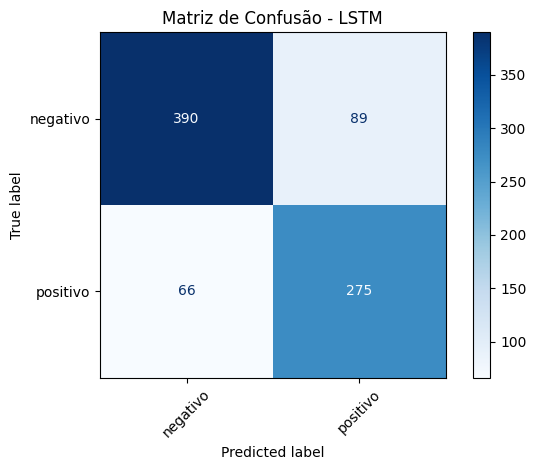

In [33]:
# Gerar matriz de confusão
cm = confusion_matrix(true, pred)


# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - LSTM")
plt.tight_layout()
plt.show()

In [34]:
# Imprime gráfico histórico do treinamento
# import matplotlib.pyplot as plt
# def plot_graphs(history, string):
#   plt.plot(history.history[string])
#   plt.plot(history.history['val_'+string])
#   plt.xlabel("Epochs")
#   plt.ylabel(string)
#   plt.legend([string, 'val_'+string])
#   plt.show()

# plot_graphs(history_LSTM, "accuracy")
# plot_graphs(history_LSTM, "loss")

In [35]:
# Testando uma frase

txt = ["Carro mata jovem"]
seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
pred = model_LSTM.predict(padded)
labels = ['negativo', 'positivo']
print(pred, labels[np.argmax(pred)])

print("Resultado na validacao:")
score=model_LSTM.evaluate(validation_padded, validation_label_seq, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[9.434874e-05]] negativo
Resultado na validacao:
Test loss: 1.053256630897522
Test accuracy: 0.8109756112098694


### 6.2 Modelo 2 - Transformer (Binario)

#### 6.2.1 Arquitetura.

In [36]:
g = torch.Generator()
g.manual_seed(random_seed)

train_dataset_Tf_bin = TensorDataset(
    train_encodings_Tf["input_ids"],
    train_encodings_Tf["attention_mask"],
    torch.tensor(y_train_Tf_enc)
)

train_loader_Tf_bin = DataLoader(
    train_dataset_Tf_bin,
    batch_size=16,
    shuffle=True,
    generator=g
)

validation_dataset_Tf_bin = TensorDataset(
    validation_encodings_Tf["input_ids"],
    validation_encodings_Tf["attention_mask"],
    torch.tensor(y_validation_Tf_enc)
)

validation_loader_Tf_bin = DataLoader(
    validation_dataset_Tf_bin,
    batch_size=16,
    shuffle=False,
    generator=g
)

In [37]:
model_Transformer_bin = AutoModelForSequenceClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased",
    num_labels=2,
    hidden_dropout_prob=0.25,
    attention_probs_dropout_prob=0.25
)

model_Transformer_bin.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.25, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.25, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((

In [38]:
optimizer = torch.optim.AdamW(
    model_Transformer_bin.parameters(),
    lr=2e-5
)

criterion = torch.nn.CrossEntropyLoss()

epochs = num_epochs

for epoch in range(epochs):

    running_loss = 0
    model_Transformer_bin.train()

    for input_ids, attention_mask, labels in train_loader_Tf_bin:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_Transformer_bin(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} Loss={running_loss:.4f} concluída")

# Equivalente ao tensorflow model.summary()
summary(model_Transformer_bin)

Epoch 1/20 Loss=72.5340 concluída
Epoch 2/20 Loss=50.2332 concluída
Epoch 3/20 Loss=38.2399 concluída
Epoch 4/20 Loss=30.3825 concluída
Epoch 5/20 Loss=26.0502 concluída
Epoch 6/20 Loss=22.8077 concluída
Epoch 7/20 Loss=19.7085 concluída
Epoch 8/20 Loss=16.0181 concluída
Epoch 9/20 Loss=14.1006 concluída
Epoch 10/20 Loss=11.5275 concluída
Epoch 11/20 Loss=12.5418 concluída
Epoch 12/20 Loss=8.9228 concluída
Epoch 13/20 Loss=7.0548 concluída
Epoch 14/20 Loss=7.7472 concluída
Epoch 15/20 Loss=5.8368 concluída
Epoch 16/20 Loss=6.1380 concluída
Epoch 17/20 Loss=4.0965 concluída
Epoch 18/20 Loss=7.4442 concluída
Epoch 19/20 Loss=4.9938 concluída
Epoch 20/20 Loss=4.7061 concluída


Layer (type:depth-idx)                                       Param #
BertForSequenceClassification                                --
├─BertModel: 1-1                                             --
│    └─BertEmbeddings: 2-1                                   --
│    │    └─Embedding: 3-1                                   22,881,792
│    │    └─Embedding: 3-2                                   393,216
│    │    └─Embedding: 3-3                                   1,536
│    │    └─LayerNorm: 3-4                                   1,536
│    │    └─Dropout: 3-5                                     --
│    └─BertEncoder: 2-2                                      --
│    │    └─ModuleList: 3-6                                  85,054,464
│    └─BertPooler: 2-3                                       --
│    │    └─Linear: 3-7                                      590,592
│    │    └─Tanh: 3-8                                        --
├─Dropout: 1-2                                               --
├─L

In [39]:
model_Transformer_bin.eval()

pred = []

true = []

with torch.no_grad():

    for input_ids, attention_mask, labels in validation_loader_Tf_bin:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model_Transformer_bin(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        prediction = torch.argmax(logits,dim=1)

        pred.extend(prediction.cpu().numpy())

        true.extend(labels.numpy())


In [40]:
acc_bert_bin = accuracy_score(true, pred)

f1_bert_bin_macro = f1_score(
    true,
    pred,
    average="macro"
)

f1_bert_bin_weighted = f1_score(
    true,
    pred,
    average="weighted"
)

precision_bert_bin = precision_score(
    true,
    pred,
    average="macro"
)

recall_bert_bin = recall_score(
    true,
    pred,
    average="macro"
)

print(classification_report(true, pred))
print("Accuracy:", acc_bert_bin)
print("F1 (Macro):", f1_bert_bin_macro)
print("F1 (Weighted):", f1_bert_bin_weighted)
print("Precision:", precision_bert_bin)
print("Recall:", recall_bert_bin)

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       479
           1       0.84      0.80      0.82       341

    accuracy                           0.85       820
   macro avg       0.85      0.85      0.85       820
weighted avg       0.85      0.85      0.85       820

Accuracy: 0.8536585365853658
F1 (Macro): 0.8483082671994375
F1 (Weighted): 0.8531026644413734
Precision: 0.8513131313131312
Recall: 0.8460135056538854


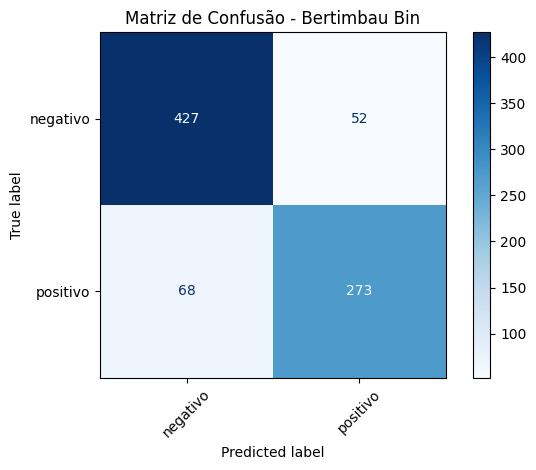

In [41]:
# Gerar matriz de confusão
cm = confusion_matrix(true, pred)


# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - Bertimbau Bin")
plt.tight_layout()
plt.show()

### 6.3 Comparação entre modelos:

In [42]:
comparacao_binaria = pd.DataFrame({

    "Modelo":[
        "LSTM - Binário",
        "Bertimbau- Binário"
    ],

    "Accuracy":[
        acc_lstm_bin,
        acc_bert_bin
    ],

    "F1-Macro":[
        f1_lstm_bin_macro,
        f1_bert_bin_macro
    ],

    "F1-Weighted":[
        f1_lstm_bin_weighted,
        f1_bert_bin_weighted
    ],

    "Precision":[
        precision_lstm_bin,
        precision_bert_bin
    ],

    "Recall":[
        recall_lstm_bin,
        recall_bert_bin
    ]

})

comparacao_binaria



,Modelo,Accuracy,F1-Macro,F1-Weighted,Precision,Recall
0,LSTM - Binário,0.810976,0.807183,0.811734,0.805379,0.810324
1,Bertimbau- Binário,0.853659,0.848308,0.853103,0.851313,0.846014


## 7. Questão 2 -

### 7.1 Modelo 3 - LSTM (Multi Classe)

#### 7.1.1 Arquitetura.

In [43]:
# Criando a rede LSTM (Long Short Term Memory)
tf.random.set_seed(random_seed)

hidden_size=64
model_LSTM_Mult = tf.keras.Sequential()
model_LSTM_Mult.add(tf.keras.layers.Embedding(vocab_size, embedding_dim))
model_LSTM_Mult.add(tf.keras.layers.LSTM(embedding_dim, dropout = 0.25 , return_sequences=True))
model_LSTM_Mult.add(tf.keras.layers.LSTM(embedding_dim, dropout = 0.25))
#model_LSTM_Mult.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)))
model_LSTM_Mult.add(tf.keras.layers.Dense(64, activation='relu'))
model_LSTM_Mult.add(tf.keras.layers.Dense(7, activation='softmax'))

#### 7.1.2 Treinamento

In [44]:
# Compilando a LSTM
model_LSTM_Mult.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
                                                 
# Treinamento da LSTM Mult
num_epochs = num_epochs
history_Mult = model_LSTM_Mult.fit(train_padded_Mult, 
                         training_label_seq_Mult, 
                         epochs=num_epochs, 
                         validation_data=(validation_padded_Mult, validation_label_seq_Mult), 
                         verbose=2)

model_LSTM_Mult.summary()

Epoch 1/20
60/60 - 4s - 63ms/step - accuracy: 0.2327 - loss: 1.8628 - val_accuracy: 0.3000 - val_loss: 1.7605
Epoch 2/20
60/60 - 1s - 16ms/step - accuracy: 0.4503 - loss: 1.3945 - val_accuracy: 0.4524 - val_loss: 1.5071
Epoch 3/20
60/60 - 1s - 15ms/step - accuracy: 0.6454 - loss: 0.9768 - val_accuracy: 0.5146 - val_loss: 1.4993
Epoch 4/20
60/60 - 1s - 18ms/step - accuracy: 0.7427 - loss: 0.7774 - val_accuracy: 0.5098 - val_loss: 1.5110
Epoch 5/20
60/60 - 1s - 17ms/step - accuracy: 0.7850 - loss: 0.6469 - val_accuracy: 0.5244 - val_loss: 1.5500
Epoch 6/20
60/60 - 1s - 15ms/step - accuracy: 0.8081 - loss: 0.5757 - val_accuracy: 0.5293 - val_loss: 1.5092
Epoch 7/20
60/60 - 1s - 16ms/step - accuracy: 0.8169 - loss: 0.5667 - val_accuracy: 0.5561 - val_loss: 1.5438
Epoch 8/20
60/60 - 1s - 15ms/step - accuracy: 0.8138 - loss: 0.5397 - val_accuracy: 0.5439 - val_loss: 1.7048
Epoch 9/20
60/60 - 1s - 16ms/step - accuracy: 0.8520 - loss: 0.4575 - val_accuracy: 0.5841 - val_loss: 1.6781
Epoch 10/2

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,735,639 (10.44 MB)

 Trainable params: 911,879 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,823,760 (6.96 MB)

#### 7.1.3 Avaliação:

In [45]:
pred = model_LSTM_Mult.predict(validation_padded_Mult)

pred = np.argmax(pred, axis=1)

true = validation_label_seq_Mult.flatten()

acc_lstm_mult = accuracy_score(true, pred)

f1_lstm_mult_macro = f1_score(
    true,
    pred,
    average="macro"
)

f1_lstm_mult_weighted = f1_score(
    true,
    pred,
    average="weighted"
)

precision_lstm_mult = precision_score(
    true,
    pred,
    average="macro"
)

recall_lstm_mult = recall_score(
    true,
    pred,
    average="macro"
)

print(classification_report(true, pred))
print("Accuracy:", acc_lstm_mult)
print("F1 (Macro):", f1_lstm_mult_macro)
print("F1 (Weighted):", f1_lstm_mult_weighted)
print("Precision:", precision_lstm_mult)
print("Recall:", recall_lstm_mult)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       0.57      0.62      0.59       182
           1       0.59      0.59      0.59       155
           2       0.57      0.63      0.60       148
           3       0.63      0.70      0.66        92
           4       0.60      0.49      0.54        84
           5       0.78      0.67      0.72        84
           6       0.25      0.20      0.22        75

    accuracy                           0.58       820
   macro avg       0.57      0.56      0.56       820
weighted avg       0.58      0.58      0.57       820

Accuracy: 0.5780487804878048
F1 (Macro): 0.560326411962172
F1 (Weighted): 0.5747816975971766
Precision: 0.5692628542732038
Recall: 0.5561742807184602


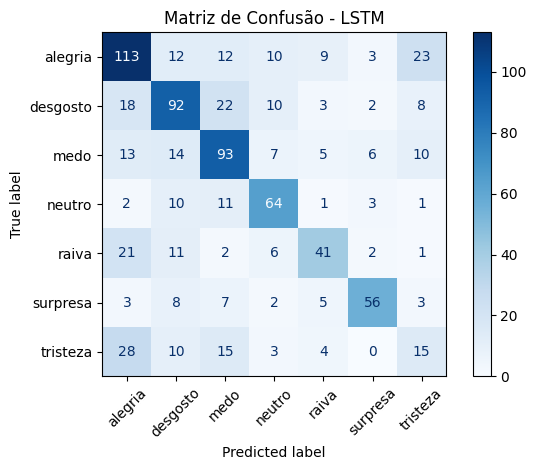

In [46]:
# Gerar matriz de confusão
cm = confusion_matrix(true, pred)

# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder_Mult.classes_
    )

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - LSTM")
plt.tight_layout()
plt.show()


In [47]:
# Imprime gráfico histórico do treinamento
# import matplotlib.pyplot as plt
# def plot_graphs(history, string):
#   plt.plot(history.history[string])
#   plt.plot(history.history['val_'+string])
#   plt.xlabel("Epochs")
#   plt.ylabel(string)
#   plt.legend([string, 'val_'+string])
#   plt.show()

# plot_graphs(history_Mult, "accuracy")
# plot_graphs(history_Mult, "loss")

In [48]:
# Testando uma frase

txt = ["Carro mata jovem"]
seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
pred = model_LSTM_Mult.predict(padded)
labels = ['alegria', 'tristeza', 'desgosto', 'medo', 'surpresa', 'raiva', 'neutro']
print(pred, labels[np.argmax(pred)])

print("Resultado na validacao:")
score=model_LSTM_Mult.evaluate(validation_padded_Mult, validation_label_seq_Mult, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[1.5523492e-05 2.6548333e-02 7.0497027e-04 5.3860345e-03 2.5214747e-04
  9.6708953e-01 3.4970835e-06]] raiva
Resultado na validacao:
Test loss: 2.3433759212493896
Test accuracy: 0.5780487656593323


### 7.2 Transformer (Multi)

In [49]:
g = torch.Generator()
g.manual_seed(random_seed)

train_dataset_Tf_Mult = TensorDataset(
    train_encodings_Tf_Mult["input_ids"],
    train_encodings_Tf_Mult["attention_mask"],
    torch.tensor(y_train_Tf_enc_Mult)
)

train_loader_Tf_Mult = DataLoader(
    train_dataset_Tf_Mult,
    batch_size=16,
    shuffle=True,
    generator=g
)

validation_dataset_Tf_Mult = TensorDataset(
    validation_encodings_Tf_Mult["input_ids"],
    validation_encodings_Tf_Mult["attention_mask"],
    torch.tensor(y_validation_Tf_enc_Mult)
)

validation_loader_Tf_Mult = DataLoader(
    validation_dataset_Tf_Mult,
    batch_size=16,
    shuffle=False,
    generator=g
)

In [50]:
model_Transformer_Mult = AutoModelForSequenceClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased",
    num_labels=7,
    hidden_dropout_prob=0.25,
    attention_probs_dropout_prob=0.25
)

model_Transformer_Mult.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.25, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.25, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((

In [51]:
optimizer = torch.optim.AdamW(
    model_Transformer_Mult.parameters(),
    lr=2e-5
)

criterion = torch.nn.CrossEntropyLoss()

epochs = num_epochs

for epoch in range(epochs):

    running_loss = 0
    model_Transformer_Mult.train()

    for input_ids, attention_mask, labels in train_loader_Tf_Mult:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_Transformer_Mult(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} Loss={running_loss:.4f} concluída")

# Equivalente ao tensorflow model.summary()
summary(model_Transformer_Mult)

Epoch 1/20 Loss=211.1261 concluída
Epoch 2/20 Loss=166.7141 concluída
Epoch 3/20 Loss=136.8417 concluída
Epoch 4/20 Loss=114.4475 concluída
Epoch 5/20 Loss=92.1385 concluída
Epoch 6/20 Loss=77.3936 concluída
Epoch 7/20 Loss=64.7345 concluída
Epoch 8/20 Loss=52.4477 concluída
Epoch 9/20 Loss=48.4757 concluída
Epoch 10/20 Loss=35.9946 concluída
Epoch 11/20 Loss=30.5654 concluída
Epoch 12/20 Loss=26.6718 concluída
Epoch 13/20 Loss=24.2932 concluída
Epoch 14/20 Loss=21.9781 concluída
Epoch 15/20 Loss=16.9356 concluída
Epoch 16/20 Loss=15.5898 concluída
Epoch 17/20 Loss=11.8662 concluída
Epoch 18/20 Loss=12.2286 concluída
Epoch 19/20 Loss=8.9269 concluída
Epoch 20/20 Loss=8.1297 concluída


Layer (type:depth-idx)                                       Param #
BertForSequenceClassification                                --
├─BertModel: 1-1                                             --
│    └─BertEmbeddings: 2-1                                   --
│    │    └─Embedding: 3-1                                   22,881,792
│    │    └─Embedding: 3-2                                   393,216
│    │    └─Embedding: 3-3                                   1,536
│    │    └─LayerNorm: 3-4                                   1,536
│    │    └─Dropout: 3-5                                     --
│    └─BertEncoder: 2-2                                      --
│    │    └─ModuleList: 3-6                                  85,054,464
│    └─BertPooler: 2-3                                       --
│    │    └─Linear: 3-7                                      590,592
│    │    └─Tanh: 3-8                                        --
├─Dropout: 1-2                                               --
├─L

In [52]:
model_Transformer_Mult.eval()

pred = []

true = []

with torch.no_grad():

    for input_ids, attention_mask, labels in validation_loader_Tf_Mult:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model_Transformer_Mult(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        prediction = torch.argmax(
            logits,
            dim=1
        )

        pred.extend(
            prediction.cpu().numpy()
        )

        true.extend(
            labels.numpy()
        )

In [53]:
acc_bert_mult = accuracy_score(true, pred)

f1_bert_mult_macro = f1_score(
    true,
    pred,
    average="macro"
)

f1_bert_mult_weighted = f1_score(
    true,
    pred,
    average="weighted"
)

precision_bert_mult = precision_score(
    true,
    pred,
    average="macro"
)

recall_bert_mult = recall_score(
    true,
    pred,
    average="macro"
)

print(classification_report(true, pred))
print("Accuracy:", acc_bert_mult)
print("F1 (Macro):", f1_bert_mult_macro)
print("F1 (Weighted):", f1_bert_mult_weighted)
print("Precision:", precision_bert_mult)
print("Recall:", recall_bert_mult)

              precision    recall  f1-score   support

           0       0.68      0.67      0.68       182
           1       0.53      0.68      0.60       148
           2       0.70      0.74      0.72        92
           3       0.51      0.40      0.45        75
           4       0.75      0.73      0.74        84
           5       0.75      0.79      0.77        84
           6       0.66      0.55      0.60       155

    accuracy                           0.65       820
   macro avg       0.66      0.65      0.65       820
weighted avg       0.65      0.65      0.65       820

Accuracy: 0.6487804878048781
F1 (Macro): 0.6494312570704215
F1 (Weighted): 0.6470438830344521
Precision: 0.6557333661837716
Recall: 0.64934680563813


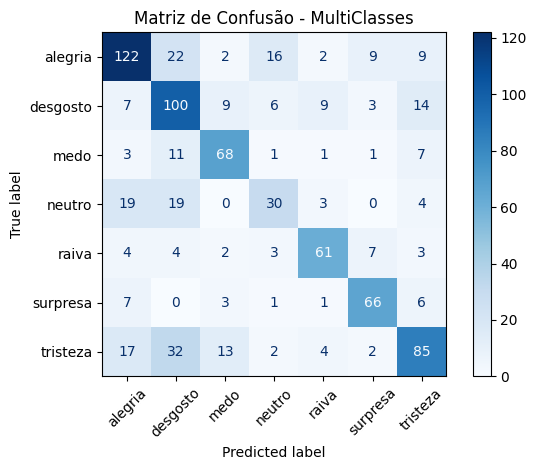

In [54]:
# Gerar matriz de confusão
cm = confusion_matrix(true, pred)

# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=label_encoder_Mult.classes_
    )
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - MultiClasses")
plt.tight_layout()
plt.show()

In [55]:
comparacao_mult = pd.DataFrame({

    "Modelo":[
        "LSTM Mult",
        "BERTimbau Mult"
    ],

    "Accuracy":[
        acc_lstm_mult,
        acc_bert_mult
    ],

    "F1-Macro":[
        f1_lstm_mult_macro,
        f1_bert_mult_macro
    ],

    "F1-Weighted":[
        f1_lstm_mult_weighted,
        f1_bert_mult_weighted
    ],

    "Precision":[
        precision_lstm_mult,
        precision_bert_mult
    ],

    "Recall":[
        recall_lstm_mult,
        recall_bert_mult
    ]

})

comparacao_mult

,Modelo,Accuracy,F1-Macro,F1-Weighted,Precision,Recall
0,LSTM Mult,0.578049,0.560326,0.574782,0.569263,0.556174
1,BERTimbau Mult,0.648780,0.649431,0.647044,0.655733,0.649347


In [57]:
resultado = pd.DataFrame([

    {
        "seed": random_seed,
        "modelo": "LSTM",
        "tarefa": "Binaria",
        "accuracy": acc_lstm_bin,
        "f1_macro": f1_lstm_bin_macro,
        "f1_weighted": f1_lstm_bin_weighted
    },

    {
        "seed": random_seed,
        "modelo": "BERTimbau",
        "tarefa": "Binaria",
        "accuracy": acc_bert_bin,
        "f1_macro": f1_bert_bin_macro,
        "f1_weighted": f1_bert_bin_weighted
    },

    {
        "seed": random_seed,
        "modelo": "LSTM",
        "tarefa": "Multiclasse",
        "accuracy": acc_lstm_mult,
        "f1_macro": f1_lstm_mult_macro,
        "f1_weighted": f1_lstm_mult_weighted
    },

    {
        "seed": random_seed,
        "modelo": "BERTimbau",
        "tarefa": "Multiclasse",
        "accuracy": acc_bert_mult,
        "f1_macro": f1_bert_mult_macro,
        "f1_weighted": f1_bert_mult_weighted
    }

])


resultado.to_csv(
    f"resultados/resultado_seed_{random_seed}.csv",
    index=False
)

resultado

,seed,modelo,tarefa,accuracy,f1_macro,f1_weighted
0,42,LSTM,Binaria,0.810976,0.807183,0.811734
1,42,BERTimbau,Binaria,0.853659,0.848308,0.853103
2,42,LSTM,Multiclasse,0.578049,0.560326,0.574782
3,42,BERTimbau,Multiclasse,0.648780,0.649431,0.647044


## Conclusões: